In [1]:
import torch
from config import ConfigGPT
from tokenizer import Tokenizer
from gpt import GPT

import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

C:\PythonProjects\python_beginners_course-main\ML_Workshop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
text_path = 'alice.txt'

In [3]:
with open(text_path, 'r', encoding='utf-8') as f:
    text = f.read()

print("Character count:", len(text))
encoder = Tokenizer()
text = encoder.train(text, num_merges=50) # mild compression (small dataset + simple model will not work well with immense tokens merging)
print("Total number of tokens:", len(text))

config = ConfigGPT(vocab_size=encoder.vocab_size)

assert  (config.num_heads * config.head_size == config.num_embed), 'Num heads mismatch'

Character count: 144016
Total number of tokens: 98082


In [4]:
def create_xy(config):
    x = []
    y = []

    context_window = [0] * config.context_length
    for i in range(len(text) - 1):
        context_window = context_window[1:] + [text[i]]
        target_window = context_window[1:] + [text[i + 1]]
        x.append(context_window)
        y.append(target_window)
    return x, y

In [5]:
x, y = create_xy(config)
n = int(0.9 * len(text))
x_train, y_train = x[:n], y[:n]
x_val, y_val = x[n:], y[n:]

print(len(x_train))
print(len(y_train))
print(len(x_val))
print(len(y_val))

print(len(x_val) / len(x)) # kinda sanity check

88273
88273
9808
9808
0.0999989804345388


In [6]:
def get_batch(config, split):
    x = x_train if split == 'train' else x_val
    y = y_train if split == 'train' else y_val
    x_batch = []
    y_batch = []
    for _ in range(config.batch_size):
        idx = np.random.randint(low=0, high=len(x))
        x_b, y_b = x[idx], y[idx]
        x_batch.append(x_b)
        y_batch.append(y_b)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(config.device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(config.device)

    return x_batch, y_batch

x_batch, y_batch = get_batch(config, 'train')
print(x_batch.shape, x_batch.dtype)

torch.Size([32, 64]) torch.int64


In [7]:
print(f"X=")
print(x_batch[0].tolist())
print()
print(f"Y=")
print(y_batch[0].tolist())

X=
[285, 266, 111, 109, 101, 272, 300, 288, 267, 115, 285, 116, 46, 276, 78, 101, 120, 262, 99, 97, 109, 256, 287, 277, 103, 114, 286, 118, 111, 105, 99, 101, 258, 148, 272, 256, 82, 97, 98, 98, 289, 282, 115, 258, 148, 268, 80, 305, 33, 32, 80, 305, 33, 32, 87, 299, 256, 97, 114, 256, 298, 63, 269, 32]

Y=
[266, 111, 109, 101, 272, 300, 288, 267, 115, 285, 116, 46, 276, 78, 101, 120, 262, 99, 97, 109, 256, 287, 277, 103, 114, 286, 118, 111, 105, 99, 101, 258, 148, 272, 256, 82, 97, 98, 98, 289, 282, 115, 258, 148, 268, 80, 305, 33, 32, 80, 305, 33, 32, 87, 299, 256, 97, 114, 256, 298, 63, 269, 32, 65]


## Training the GPT model

In [8]:
gpt = GPT(config)
optimizer = torch.optim.Adam(params=gpt.parameters(), lr=1e-2)

In [9]:
def autocomplete(start_phrase, num_tokens=100):
    enc_phrase = encoder.encode(start_phrase)
    enc_phrase = torch.tensor(enc_phrase).unsqueeze(0)
    return encoder.decode(gpt.generate(enc_phrase, num_tokens)[0].tolist())

print("GPT (Untrained) generation:\n----")
result = autocomplete("Hello,", 100)
print(result)

GPT (Untrained) generation:
----
Hello,�$�qߎli���her۪ s�,”�}1n���hay��fxing ���|�H��th�U�, �a��� a)3

“.��l٥Pit�y of}b�� a"�youth��r�r s�Ly t ���)


In [10]:
train_losses = []
val_losses = []

total_steps = 5000
loop = tqdm(range(total_steps), total=total_steps, desc='Training GPT Model')
for step in loop:
    # Train
    gpt.train()
    x_batch, y_batch = get_batch(config, 'train')
    _, loss = gpt(x_batch, y_batch)
    train_losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Evaluate
    gpt.eval()
    with torch.no_grad():
        x_batch, y_batch = get_batch(config, 'val')
        _, loss = gpt(x_batch, y_batch)
        val_losses.append(loss.item())

    loop.set_postfix(loss=f'{loss.item():.4f}')

Training GPT Model: 100%|██████████| 5000/5000 [02:58<00:00, 28.05it/s, loss=2.5796]


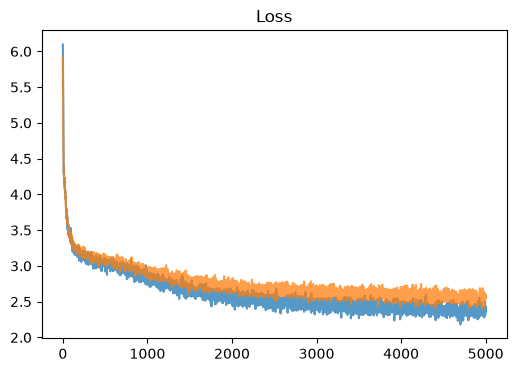

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label='Train', alpha=0.75)
plt.plot(val_losses, label='Val', alpha=0.75)
plt.title("Loss");

In [12]:
torch.save(gpt.state_dict(), 'gpt_params.pth')

In [13]:
print("GPT (Trained) generation:\n----")
result = autocomplete("Hello,", 500)
print(result)

GPT (Trained) generation:
----
Hello, and whe, and were ofd littallent! Soup, _ink to get:no and trigh—I you_ greapok OTh, _and that was a great so
the vats! She was his yep as riblather (lea bance. Foop to it acttated towfumbse, and finorke of the anse, “When the to sir I by me a hea, she liketp.

“How On’t peat wid may greming it,
was it;’s shoure Whe,
      Po shee talf are quite uber are out at Alice i his besthen
cams.

“I mumpened qubje fenke boven obits of what beot oning
batue) “Esee dooring seat her upantier: bying me of Und don the hridd and all poopbleer.

There was but as a keen you up and sate seet her


I dear.

There, and den she
ope, and she said: and, “On. Sought another beteral the coo geal an sespred agldfully
the indess anxwerep his ich agp ab
